Exercise 8.1
Write a program that, given a number N_max, generates N_toys toy experiments, each containing a sample of N_max events following a chosen distribution, and calculates their mean.

In [42]:
from generator import generate_uniform
from statistics import mean
N_toys = 100
N_max = 10
mean_list = []
for i in range(N_toys):
    sample = generate_uniform(N_max)
    mean_sample = mean(sample)
    mean_list.append(mean_sample)

Exercise 8.2
Add to the previous program a histogram that visualizes the distribution of means across the toy experiments.

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from math import ceil, floor
from stats import stats
my_stats = stats(mean_list)
xMin = my_stats.mean() - 5 * my_stats.sigma()
xMax = my_stats.mean() + 5 * my_stats.sigma()
N_bins = floor(len(mean_list)/10.)
bin_edges = np.linspace( xMin, xMax, N_bins + 1)

Text(0.5, 0, 'means')

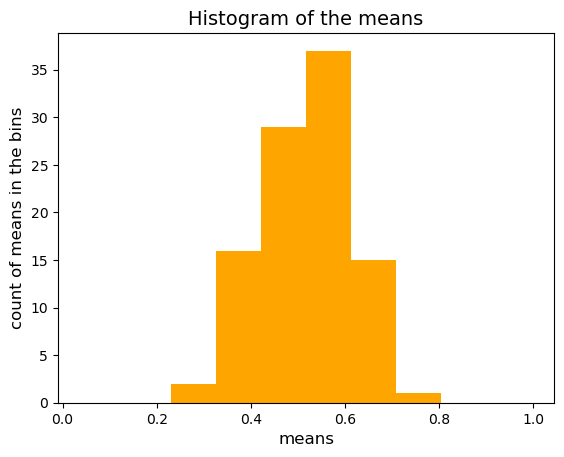

In [44]:
fig, ax = plt.subplots( nrows = 1, ncols = 1)
ax.hist( mean_list, bins = bin_edges, color = 'orange')
ax.set_title('Histogram of the means', size = 14)
ax.set_ylabel('count of means in the bins', size = 12)
ax.set_xlabel('means', size = 12)

Exercise 8.3
- Use the stats class developed during the previous Lectures to compare the standard deviation of the mean calculated for each individual toy with the standard deviation of the sample of means

In [45]:
from stats import stats
from statistics import stdev
N_toys = 100
N_max = 10
mean_list = []
stdev_list = []
for i in range(N_toys):
    sample = generate_uniform(N_max)
    my_stats = stats(sample)
    mean_list.append(my_stats.mean())
    stdev_list.append(my_stats.sigma())
stdev_of_means = stdev(mean_list)
diff_stdev = []
for i in range(len(stdev_list)):
    if stdev_list[i] > stdev_of_means: 
        diff = stdev_list[i] - stdev_of_means 
    else: 
        diff = stdev_of_means - stdev_list[i]
    diff_stdev.append(diff)
print('difference stdev of the means and stdev of each sample = ', diff_stdev)

difference stdev of the means and stdev of each sample =  [0.16321794997506273, 0.25093068867381807, 0.17283637808664903, 0.2456685977663271, 0.11060965823647875, 0.1826353343164775, 0.15832944482990208, 0.2041274270356247, 0.17889379383009263, 0.19874170769635358, 0.2031120921779508, 0.2515755126981368, 0.24304428461094868, 0.13253977074725845, 0.14947693371146956, 0.13393399050422625, 0.16838897591810342, 0.21000647512208387, 0.23592322621341838, 0.13329698195180784, 0.2517622643509531, 0.190096017358796, 0.12413627299848337, 0.16770896903835597, 0.17836316850011985, 0.1643338267899926, 0.33996693039504483, 0.25383885807820983, 0.2088767389160442, 0.27554548993042577, 0.1837334319123647, 0.23025171412493428, 0.22330013475514232, 0.1943349245602426, 0.21079291682236118, 0.20703294392468047, 0.13224036175714546, 0.27192127366296576, 0.1925311571412539, 0.14805165918901808, 0.16481432405497032, 0.10909838337511799, 0.21365156012199998, 0.17275782776676096, 0.22123981487522804, 0.2353890

Exercise 8.4

- Use two scatter plots to compare the evolution of the standard deviation of the mean calculated for each individual toy with the standard deviation of the sample of means as the number of events generated in a single toy experiment varies.


In [46]:
from stats import stats
stdev_list = []
stdev_means = []
stdev_single_list = []
N_events = []
X = []
N_toys = 10
N_min = 10
N_max = 100
while (N_min < N_max) :
    means_list = []
    for i in range(N_toys):
        randlist = generate_uniform(N_min)
        my_stats = stats(randlist)
        if i == 0:
            stdev_single_list.append(my_stats.sigma_mean())
        stdev_list.append(my_stats.sigma_mean())
        means_list.append(mean(randlist))
        X += [N_min]
    stdev_means.append(stdev(means_list))
    N_events.append(N_min)
    N_min = N_min * 2

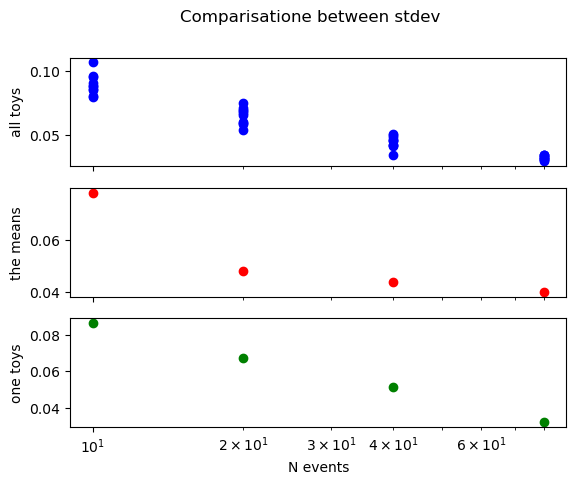

In [47]:
fig, (ax1,ax2,ax3) = plt.subplots( 3, sharex = True)
fig.suptitle('Comparisatione between stdev', size = 12)
ax1.scatter(X, stdev_list, color = 'blue')
ax1.set_ylabel('all toys', size = 10)
ax1.set_xscale('log')
ax2.scatter(N_events, stdev_means, color = 'red')
ax2.set_ylabel('the means', size = 10)
ax2.set_xscale('log')
ax3.scatter(N_events, stdev_single_list, color = 'green')
ax3.set_ylabel('one toys', size = 10)
ax3.set_xlabel('N events', size = 10)
ax3.set_xscale('log')

Exercise 8.5

- Implement the hit-or-miss integration method with the example function f(x) = sin(x).
- Write the algorithm that calculates the integral as function external to the main program, ensuring it takes as input parameters the limits along the x and y axis, as well as the number of pseudo-random points to generate.
- Make sure the algorithm returns a container with two elements: the first element is the value of the integral, the second is its uncertainty.



In [48]:
def function (x):
    return 1. + sin(x)

In [49]:
from integral import integral_HOM
from math import sin 
func = function
xMin = 0
xMax = 2*np.pi
yMax = 2
N_evt = 1000
value_area, sigma_area = integral_HOM (func, xMin, xMax, yMax, N_evt)
print( str(value_area) +' +- '+ str(sigma_area))

5.91876055936317 +- 0.03934561220753638


In [50]:
from integral import integral_HOM
from math import sin 
func = function
xMin = 0
xMax = 2*np.pi
yMax = 2
N_evt = 1000
value_area, sigma_area = integral_HOM (func, xMin, xMax, yMax, N_evt)
print( str(value_area) +' +- '+ str(sigma_area))

6.2957516777939455 +- 0.03947825969068701


Exercise 8.6

- Insert the calculation of the integral from the previous exercise into a loop that, as the number N of generated points varies, displays the value of the integral and its uncertainty.
- Use a scatter plot to visualize the trends of the integral value and its uncertainty as N varies on a logarithmic scale.


In [51]:
func = function
xMin = 0
xMax = 2*np.pi
yMax = 2
N_max = 10000
N_min = 500
N_evt = []
values_area = []
sigmas_area = []
while (N_min < N_max) :
    value_area, sigma_area = integral_HOM( func, xMin, xMax, yMax, N_min)
    values_area.append(value_area)
    sigmas_area.append(sigma_area)
    N_evt += [N_min]
    N_min = N_min + 500

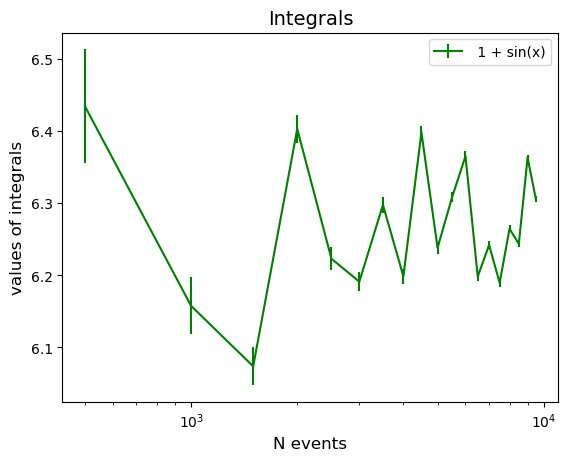

In [58]:
fig, ax = plt.subplots()
ax.errorbar(N_evt, values_area, xerr = 0.0, yerr = sigmas_area, color = 'green', label = ' 1 + sin(x)')
ax.set_title('Integrals', size = 14)
ax.set_ylabel('values of integrals', size = 12)
ax.set_xlabel('N events', size = 12)
ax.set_xscale('log')
ax.legend()
plt.show()

Exercise 8.7

- Implement the crude-MC integration method with the example function f(x) = sin(x).
- Write the algorithm that calculates the integral as a function external to the main program, ensuring it takes as input parameters the limits along the x axis and the number of pseudo-random points to generate.
- Make sure the algorithm returns a container with two elements: the first element is the value of the integral, the second is its uncertainty.


In [53]:
from integral import integral_CrudeMC
g = function
xMin = 0
xMax = 2*np.pi
yMax = 2
N_rand = 1000
integral, sigma_integral = integral_CrudeMC (g, xMin, xMax, N_rand)
print( str(integral) + ' +- ' + str(sigma_integral) )

6.3619402193614265 +- 0.14084360855557856


Exercise 8.8

- Insert the calculation of the integral from the previous exercise into a loop that, as the number N of generated points varies, displays the value of the integral and its uncertainty.
- Plot the trends of the integral value and its uncertainty as N varies on a logarithmic scale.
- Overlay this behavior with the one obtained from completing Exercise 8.6.


In [55]:
g = function
xMin = 0
xMax = 2*np.pi
yMax = 2
N_max = 10000
N_min = 500
N_evt = []
integrals_MC = []
sigmas_MC = []
while (N_min < N_max) :
    integral, sigma_MC = integral_CrudeMC( g, xMin, xMax, N_min)
    integrals_MC.append(integral)
    sigmas_MC.append(sigma_MC)
    N_evt += [N_min]
    N_min = N_min + 500

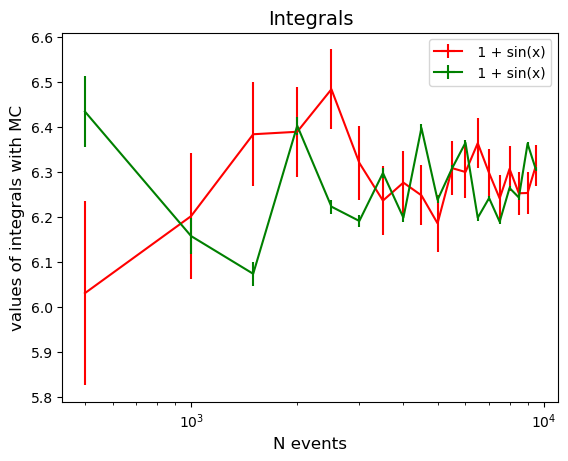

In [60]:
fig, ax = plt.subplots()
ax.errorbar(N_evt, integrals_MC, xerr = 0.0, yerr = sigmas_MC, color = 'red', label = ' 1 + sin(x)')
ax.errorbar(N_evt, values_area, xerr = 0.0, yerr = sigmas_area, color = 'green', label = ' 1 + sin(x)')
ax.set_title('Integrals', size = 14)
ax.set_ylabel('values of integrals with MC', size = 12)
ax.set_xlabel('N events', size = 12)
ax.set_xscale('log')
ax.legend()
plt.show()

Exercise 8.9

- Use the hit-or-miss method to estimate the integral underlying a Gaussian probability distribution with μ=0 and σ=1 within a generic interval [a,b].
- Calculate the integral contained within the intervals [-kσ, kσ] as k varies from 1 to 5.


In [63]:
from scipy.stats import norm
mean = 0
sigma = 1
func = norm.pdf
N_evt = 1000
xMin = -0.5
xMax = 0.5
yMax = norm.pdf(0,0,1)
integral, sigma_integral = integral_HOM (func, xMin, xMax, yMax, N_evt)
print( str(integral) + ' +- ' + str(sigma_integral))

0.38298458918537537 +- 6.111549814728786e-06


In [ ]:
for i in range(1,6):
    integral, sigma_integral = integral_HOM( func, - float(i), float(i)